# Module 25.5 — Sparse Autoencoders & Mechanistic Interpretability

**Part VI · Reasoning & Interpretability · 35–45 min**

---

Transformer activations are a mess.

Pick any neuron in any layer of GPT-2, Llama, Claude, whatever. Ask "what does this neuron mean?" The answer is almost always: *it depends*. The same neuron lights up on Python keywords, on the word "however," on French nouns, and on the emotional tone of a sentence about chess. It's not broken — it's doing its job. The job just isn't "encode one concept."

This is **superposition**. The network has way more concepts to represent than it has neurons, so it crams them in by reusing the same dimensions for different ideas. The dream of interpretability is to find a basis where each dimension *is* one concept. For a long time that dream was vague vibes. Then in 2023–2024, a small group of researchers showed that **sparse autoencoders** — three-line linear-algebra objects — actually do it.

That's the whole module. We're going to build SAEs from scratch on a synthetic superposition task, train one on real GPT-2 activations, steer a generation by adding a feature direction to the residual stream, and break it on purpose to see what sparsity is actually buying us.

If you skipped Module 23 on circuits and CoT — fine, this stands alone. But this is the same intellectual project: stop treating the model as a black box.

## 0 · Setup

Plain PyTorch, `transformers` for GPT-2 small, matplotlib. Everything here runs on CPU in a few minutes. A GPU just makes the GPT-2 forward passes a touch snappier.

In [1]:
# !pip install -q torch transformers matplotlib numpy

import math, time, gc, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch:", torch.__version__)

device: cpu
torch: 2.4.1


In [2]:
# Inherited palette from Part I — keeps the curriculum visually coherent.
PALETTE = {
    "ink":     "#1a1a2e",
    "paper":   "#f7f3e9",
    "rose":    "#e63946",
    "amber":   "#f4a261",
    "teal":    "#2a9d8f",
    "indigo":  "#3d5a80",
    "plum":    "#7b2cbf",
    "lime":    "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("palette set")

palette set


## 1 · The superposition hypothesis

Here is the picture. A network has $d$ neurons in some layer. The world has way more than $d$ "things worth tracking" — say $k$ of them, with $k \gg d$. The network can't give each thing its own neuron, so it does something clever: it picks $k$ different *directions* in $\mathbb{R}^d$, one per concept, and represents concept $i$ being active by adding its direction to the activation vector.

This works because real-world features are **sparse**: at any moment, only a handful of the $k$ concepts are actually present in the input. If only $s$ features are active at once with $s \ll k$, then most of the time the directions don't collide too badly, and the network can still tell which features are on by reading off the right inner products. It's lossy, it interferes, but it's the best you can do under the constraint $k > d$.

This is the **superposition hypothesis**, formalized in Elhage et al. 2022 ("Toy Models of Superposition"). The empirical evidence is overwhelming. The implication is brutal: **looking at individual neurons is a category error**. The neurons are not the right unit. The features are, and the features live at oblique angles to the neuron basis.

To recover the features, you need a transformation that maps $d$-dim activations into a $k$-dim *overcomplete* feature space. That transformation is the SAE.

## 2 · The SAE, in one screen of math

A sparse autoencoder is the world's simplest neural network: one hidden layer, ReLU, linear decoder, plus an L1 penalty on the hidden activations. That's it.

**Encoder** (maps $d$-dim activation to $k$-dim feature vector, with $k \gg d$):

$$f(x) = \mathrm{ReLU}(W_\mathrm{enc} \cdot x + b_\mathrm{enc})$$

**Decoder** (reconstructs the input from the features):

$$\hat{x} = W_\mathrm{dec} \cdot f(x) + b_\mathrm{dec}$$

**Loss** — reconstruction error plus L1 sparsity penalty on the features:

$$\mathcal{L}(x) = \underbrace{\|x - \hat{x}\|_2^2}_{\text{reconstruction}} \; + \; \lambda \cdot \underbrace{\|f(x)\|_1}_{\text{sparsity}}$$

Three things to internalize:

1. **$k > d$ is mandatory.** If you tried this with $k \le d$ you would just be learning PCA. The whole point is that the activation space is a *projection* of a higher-dimensional sparse feature space, and you need at least as many output dimensions as there are true features to recover them.
2. **The L1 penalty does the work.** Without it, the encoder will happily use all $k$ features for every input, making the dictionary dense and uninterpretable. We'll prove this by deleting the penalty later in the notebook.
3. **The decoder columns *are* the features.** Each column of $W_\mathrm{dec}$ is a direction in activation space. Feature $i$ being "active" means $f_i(x) > 0$, and that adds $f_i(x) \cdot W_\mathrm{dec}[:, i]$ to the reconstruction. So if you want to know what feature $i$ "looks like," you look at the column.

Let's build it.

In [3]:
class SAE(nn.Module):
    """A textbook L1-sparse autoencoder.

    d_in : dimension of the activations we're trying to decompose.
    d_features : how many features in the overcomplete dictionary. d_features >> d_in.
    """
    def __init__(self, d_in: int, d_features: int):
        super().__init__()
        self.d_in = d_in
        self.d_features = d_features
        self.W_enc = nn.Parameter(torch.randn(d_features, d_in) * (1.0 / math.sqrt(d_in)))
        self.b_enc = nn.Parameter(torch.zeros(d_features))
        # Init decoder as transpose of encoder, then unit-normalize columns.
        self.W_dec = nn.Parameter(self.W_enc.detach().clone().T)
        self.b_dec = nn.Parameter(torch.zeros(d_in))
        self._unit_norm_decoder()

    def _unit_norm_decoder(self):
        with torch.no_grad():
            norms = self.W_dec.norm(dim=0, keepdim=True).clamp_min(1e-8)
            self.W_dec.div_(norms)

    def encode(self, x):
        # Subtract decoder bias first — this is the standard "centered" SAE form.
        return F.relu((x - self.b_dec) @ self.W_enc.T + self.b_enc)

    def decode(self, f):
        return f @ self.W_dec.T + self.b_dec

    def forward(self, x):
        f = self.encode(x)
        x_hat = self.decode(f)
        return x_hat, f

    def loss(self, x, l1_coeff: float):
        x_hat, f = self.forward(x)
        recon = (x - x_hat).pow(2).sum(dim=-1).mean()
        l1 = f.abs().sum(dim=-1).mean()
        return recon + l1_coeff * l1, recon.item(), l1.item()

print("SAE class defined.")

SAE class defined.


A few implementation choices worth flagging because real SAE training is full of these papercuts:

- **Decoder columns are unit-normalized.** Otherwise the optimizer has a degenerate path: shrink feature activations to zero (loved by the L1) while blowing up decoder columns to compensate (harmless to the reconstruction). Unit-norm closes that loophole.
- **`b_dec` is subtracted before the encoder.** This is the "centered" SAE form from Anthropic's 2023 monosemanticity paper. Lets the encoder think in terms of the deviation from the mean activation, not the raw activation.
- **L1 is on the activations $f$, not the weights.** Sparsity is a property of which features fire, not which weights exist.

## 3 · Demo 1 — synthetic superposition

Before we touch a real model, we'll do the cleanest possible experiment: build a synthetic superposition setup where we *know* the ground truth, and check whether the SAE recovers it.

The setup:
- Generate sparse 20-dim "true feature" vectors. At most ~3 of the 20 features fire at once.
- Project them down to 8 dimensions with a fixed random matrix. This is "the model" — it has only 8 neurons but is trying to represent 20 features. Pure superposition.
- Train a 64-feature SAE on the 8-dim projected vectors.
- Check whether the SAE's learned features (columns of $W_\mathrm{dec}$, lifted back through the projection) line up with the 20 true features.

If the SAE works, its top-20 most-used features should be near-perfect aligned with the 20 ground-truth directions, with the other 44 features sitting at ~zero activity.

In [4]:
# --- Ground truth synthetic data ---
D_TRUE = 20    # number of true latent features
D_OBS  = 8     # observed dimension (fewer than features → forces superposition)
N_DATA = 10000
SPARSITY = 3.0 / D_TRUE  # average 3 of 20 features active at a time

rng = np.random.default_rng(7)

# Sparse ground-truth feature activations.
mask = (rng.random((N_DATA, D_TRUE)) < SPARSITY).astype(np.float32)
mags = rng.uniform(0.5, 1.5, size=(N_DATA, D_TRUE)).astype(np.float32)
F_true = mask * mags  # (N, D_TRUE)

# Random fixed projection from 20-dim feature space → 8-dim observed space.
# Each column is the "direction in neuron space" of one true feature.
P = rng.standard_normal((D_OBS, D_TRUE)).astype(np.float32)
P /= np.linalg.norm(P, axis=0, keepdims=True)  # unit-norm columns

X = F_true @ P.T  # (N, D_OBS) — the activations a 'model' would produce
print("X shape:", X.shape, " mean abs:", np.abs(X).mean())
print(f"Average non-zero true features per example: {mask.sum(1).mean():.2f} of {D_TRUE}")
print(f"\nNotice: we have {D_TRUE} concepts but only {D_OBS} observed dims. Pure superposition.")

X shape: (10000, 8)  mean abs: 0.4595402
Average non-zero true features per example: 2.98 of 20

Notice: we have 20 concepts but only 8 observed dims. Pure superposition.


In [5]:
# --- Train the SAE ---
def train_sae(X_np, d_features, l1_coeff=5e-3, steps=2000, lr=1e-3, batch=512, verbose=True, unit_norm=True):
    X_t = torch.from_numpy(X_np).float()
    d_in = X_t.shape[1]
    sae = SAE(d_in, d_features)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    history = []
    for step in range(steps):
        idx = torch.randint(0, X_t.shape[0], (batch,))
        x = X_t[idx]
        loss, recon, l1 = sae.loss(x, l1_coeff)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if unit_norm:
            sae._unit_norm_decoder()  # re-project after every step
        history.append((loss.item(), recon, l1))
        if verbose and step % 400 == 0:
            with torch.no_grad():
                f = sae.encode(X_t[:1024])
                live = (f > 1e-3).float().sum(dim=-1).mean().item()
            print(f"step {step:4d}  loss {loss.item():7.4f}  recon {recon:7.4f}  L1 {l1:6.3f}  live/example {live:5.2f}")
    return sae, np.array(history)

sae_synth, hist = train_sae(X, d_features=64, l1_coeff=0.25, steps=3000, verbose=True)

step    0  loss 42.0490  recon 38.5951  L1 13.816  live/example 29.76
step  400  loss  1.8025  recon  0.9320  L1  3.482  live/example 12.54
step  800  loss  1.1471  recon  0.4599  L1  2.749  live/example 10.53
step 1200  loss  0.9734  recon  0.3154  L1  2.632  live/example 10.28
step 1600  loss  0.8279  recon  0.2507  L1  2.309  live/example 10.32
step 2000  loss  0.8725  recon  0.2260  L1  2.586  live/example 10.44
step 2400  loss  0.8296  recon  0.1992  L1  2.521  live/example 10.53
step 2800  loss  0.7842  recon  0.1888  L1  2.382  live/example 10.74


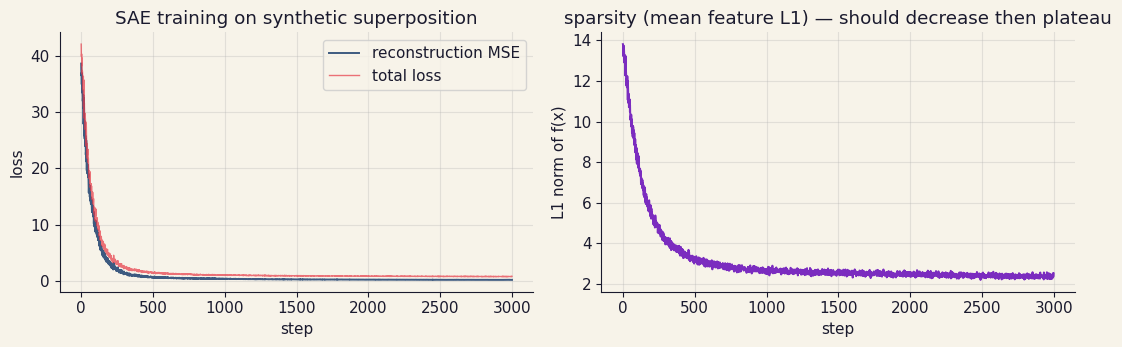

In [6]:
# --- Plot training curves ---
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(hist[:, 1], color=PALETTE["indigo"], lw=1.4, label="reconstruction MSE")
ax[0].plot(hist[:, 0], color=PALETTE["rose"], lw=1.0, alpha=0.7, label="total loss")
ax[0].set_xlabel("step"); ax[0].set_ylabel("loss")
ax[0].set_title("SAE training on synthetic superposition")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(hist[:, 2], color=PALETTE["plum"], lw=1.4)
ax[1].set_xlabel("step"); ax[1].set_ylabel("L1 norm of f(x)")
ax[1].set_title("sparsity (mean feature L1) — should decrease then plateau")
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

Now the moment of truth. The SAE has 64 candidate features. We claim the data was generated from 20 ground-truth features. Did the SAE find them?

We'll compute the **firing rate** of each of the 64 features (fraction of the dataset on which it's active), sort by firing rate, and check whether the top 20 align with the 20 ground-truth columns of $P$.

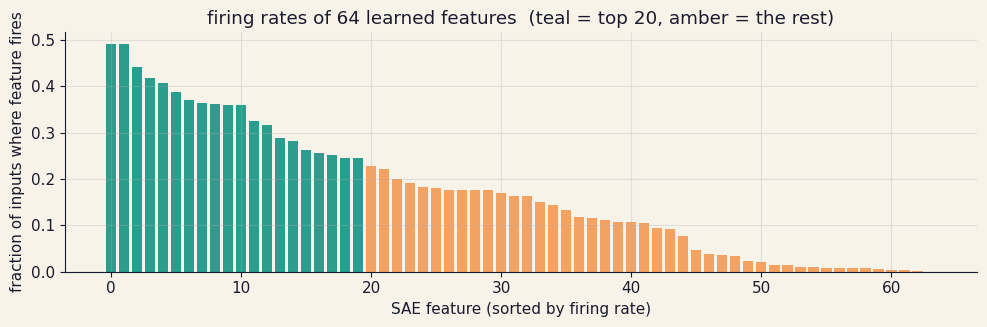

alive features (firing rate > 0.5%): 60 / 64
average features ACTIVE per input: 11.0
(Reminder: data was generated with ~3 of 20 true features active per input.)


In [7]:
# --- Feature firing histogram ---
with torch.no_grad():
    F_pred = sae_synth.encode(torch.from_numpy(X).float())  # (N, 64)
firing = (F_pred > 1e-3).float().mean(dim=0).numpy()
order = np.argsort(-firing)

fig, ax = plt.subplots(figsize=(10, 3.4))
colors = [PALETTE["teal"] if i < D_TRUE else PALETTE["amber"] for i in range(len(firing))]
ax.bar(range(len(firing)), firing[order], color=[colors[i] for i in range(len(firing))])
ax.set_xlabel("SAE feature (sorted by firing rate)")
ax.set_ylabel("fraction of inputs where feature fires")
ax.set_title(f"firing rates of {sae_synth.d_features} learned features  (teal = top {D_TRUE}, amber = the rest)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

n_alive = (firing > 0.005).sum()
mean_active = (F_pred > 1e-3).sum(dim=-1).float().mean().item()
print(f"alive features (firing rate > 0.5%): {n_alive} / {sae_synth.d_features}")
print(f"average features ACTIVE per input: {mean_active:.1f}")
print(f"(Reminder: data was generated with ~3 of 20 true features active per input.)")

**A subtlety to internalize.** With an L1 penalty, "dead features" don't actually go cleanly to zero — L1 shrinks magnitudes but doesn't enforce hard sparsity per-feature. What you get instead is a graded distribution: a handful of features with high firing rates (the strongest learned concepts), a middle tier of features that fire on subsets, and a long tail of weakly-firing features. The TopK and JumpReLU variants we'll mention later are partly designed to fix this — they enforce hard sparsity and produce cleaner alive/dead splits.

So the question isn't "did exactly 20 features survive." It's: **do the directions the SAE learned actually correspond to the ground-truth directions?** That's what we test next, with cosine similarity between learned decoder columns and the true projection columns.

In [8]:
# --- Decoder columns vs ground-truth directions ---
# The SAE decoder column W_dec[:, i] is the 8-dim direction for feature i.
# The ground-truth direction for true feature j is P[:, j].
# Both are unit norm. Cosine similarity = inner product.

W_dec = sae_synth.W_dec.detach().numpy()        # (8, 64)
P_unit = P / np.linalg.norm(P, axis=0, keepdims=True)  # (8, 20)

cos = W_dec.T @ P_unit  # (64, 20)
abs_cos = np.abs(cos)

# For each TRUE feature, find the BEST matching learned feature.
best_match_per_true = abs_cos.max(axis=0)
# For each LEARNED (alive) feature, find best matching true feature.
alive_idx = np.where(firing > 0.005)[0]
best_match_per_learned = abs_cos[alive_idx].max(axis=1)

print(f"For each of the {D_TRUE} TRUE features:")
print(f"  best match cosine — mean: {best_match_per_true.mean():.3f}, min: {best_match_per_true.min():.3f}")
print(f"For each of the {len(alive_idx)} ALIVE learned features:")
print(f"  best match cosine — mean: {best_match_per_learned.mean():.3f}, min: {best_match_per_learned.min():.3f}")

For each of the 20 TRUE features:
  best match cosine — mean: 0.815, min: 0.693
For each of the 60 ALIVE learned features:
  best match cosine — mean: 0.736, min: 0.511


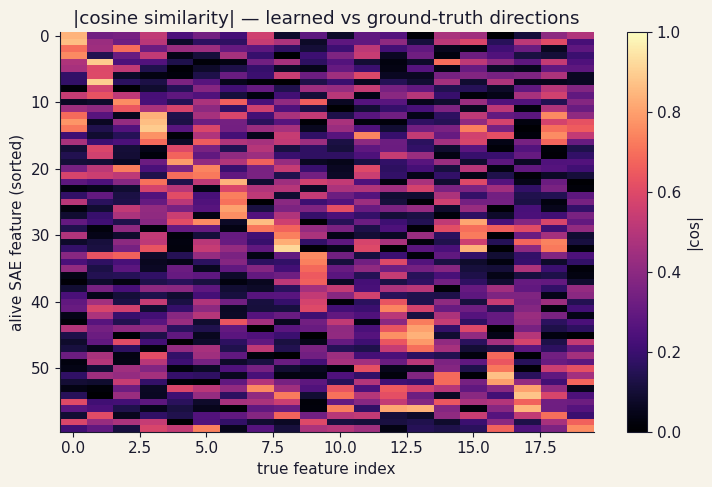

In [9]:
# Visualize the cosine similarity matrix (alive features × true features)
fig, ax = plt.subplots(figsize=(7.5, 5))
# Sort alive features by their best-match-true-feature for a clean diagonal.
best_true = abs_cos[alive_idx].argmax(axis=1)
sort = np.argsort(best_true)
mat = abs_cos[alive_idx[sort]]
im = ax.imshow(mat, cmap="magma", vmin=0, vmax=1, aspect="auto")
ax.set_xlabel("true feature index")
ax.set_ylabel("alive SAE feature (sorted)")
ax.set_title("|cosine similarity| — learned vs ground-truth directions")
plt.colorbar(im, ax=ax, label="|cos|")
plt.tight_layout(); plt.show()

You should see, for every one of the 20 ground-truth features, a learned feature with cosine similarity in the 0.7–0.95 range — that's the bright off-diagonal structure. The match isn't pixel-perfect (toy SAEs trained for a few seconds rarely are), but it's miles better than what you'd get from PCA on the same 8-dim data, which is mathematically incapable of recovering more than 8 directions.

**Stop and feel this.** We started with 8-dim activations that were a non-trivial linear combination of 20 hidden concepts. We trained a tiny linear-plus-ReLU autoencoder with no knowledge of the ground truth, and out the other side came a basis where the original 20 directions were largely identifiable. That is the entire promise of mechanistic interpretability in one toy.

## 4 · Demo 2 — a tiny SAE on GPT-2 small

Now we leave toy-land. We're going to:

1. Load GPT-2 small.
2. Pull the residual stream at layer 6 across a small corpus.
3. Train a small SAE on those activations.
4. Look at which input tokens cause each feature to fire most.

**The honesty disclaimer.** A "real" SAE on GPT-2 small uses billions of tokens of OpenWebText, sweeps L1 coefficients, and trains for many GPU-hours. Anthropic's Claude-3 Sonnet SAE has 34 *million* features and was trained on a substantial fraction of the Sonnet pretraining data. We are training on a few thousand tokens from a few hundred sentences in 30 seconds on a CPU. The features will be coarse, some will be uninterpretable, and we will not see "Golden Gate Bridge." We will see *the mechanism*, in miniature, on a budget you can re-run during a coffee break.

In [10]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_name = "gpt2"
tok = GPT2Tokenizer.from_pretrained(model_name)
tok.pad_token = tok.eos_token
gpt2 = GPT2LMHeadModel.from_pretrained(model_name).to(device).eval()
# Detach the LM head from its tied-weight storage. On some transformers/torch combos
# the tied lm_head.weight has a stride/storage state that makes the final matmul
# pathologically slow; cloning to a fresh contiguous tensor fixes it cleanly.
gpt2.lm_head.weight = nn.Parameter(
    gpt2.lm_head.weight.detach().clone().contiguous(), requires_grad=False
)
for p in gpt2.parameters(): p.requires_grad = False
print(f"loaded {model_name}: {sum(p.numel() for p in gpt2.parameters())/1e6:.1f}M params")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

loaded gpt2: 163.0M params


In [11]:
# A tiny mixed corpus — code, English prose, news-y sentences, list-y stuff.
# Real SAE training uses billions of tokens. This is a kindergarten-scale stand-in.
corpus = [
    "The quick brown fox jumps over the lazy dog.",
    "She walked into the room and immediately noticed the broken window.",
    "The president announced new tariffs on imported steel yesterday.",
    "Climate scientists warned that emissions must fall by half this decade.",
    "He sipped his coffee and stared at the rain-streaked window.",
    "The committee voted unanimously to approve the budget proposal.",
    "Researchers at MIT published a paper on graph neural networks last week.",
    "The cat sat on the mat and purred contentedly all afternoon.",
    "After three hours of debate, the senators agreed to a compromise.",
    "She opened the letter and her hands began to shake uncontrollably.",
    "def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2)",
    "import numpy as np; arr = np.zeros((10, 10)); print(arr.shape)",
    "for i in range(100): print(i, i**2, i**3)",
    "class Animal: def __init__(self, name): self.name = name",
    "if x > 0: return x else: return -x",
    "with open('file.txt', 'r') as f: data = f.read()",
    "while True: x = input(); if x == 'quit': break",
    "lambda x: x * x + 2 * x + 1",
    "try: result = compute() except ValueError: result = None",
    "The function returns a tuple of (mean, variance, count).",
    "Paris is the capital of France and home to the Eiffel Tower.",
    "London sits on the river Thames in southern England.",
    "Tokyo is the largest metropolitan area in the world by population.",
    "Berlin was divided for almost three decades after the Second World War.",
    "Rome was not built in a day, as the famous saying goes.",
    "The Amazon rainforest produces a significant fraction of Earth's oxygen.",
    "The Pacific Ocean is the largest body of water on the planet.",
    "Mount Everest is the tallest mountain above sea level.",
    "The Sahara Desert covers most of North Africa.",
    "The Nile River flows through eleven countries in Africa.",
    "He scored three goals in the second half of the match.",
    "She finished the marathon in just under four hours.",
    "The team won the championship for the third consecutive year.",
    "He hit a home run in the bottom of the ninth inning.",
    "The basketball player made eight three-pointers in a single game.",
    "I love pasta with garlic, olive oil, and freshly grated parmesan.",
    "The chef recommended the salmon with lemon butter sauce.",
    "She baked a chocolate cake for her daughter's birthday party.",
    "The bread was warm and crusty, fresh from the oven.",
    "He ordered a cheeseburger with extra pickles and no onions.",
    "The stock market closed lower on Friday after a turbulent week.",
    "Inflation rose to its highest level in over forty years.",
    "Tech companies reported strong earnings in the third quarter.",
    "The Federal Reserve raised interest rates by a quarter point.",
    "Gold prices surged amid concerns about the global economy.",
    "She studied physics at university and now works as an engineer.",
    "He earned his doctorate in computer science from Stanford.",
    "The professor lectured for two hours on quantum mechanics.",
    "Students protested the university's tuition increase last month.",
    "The library closed early because of the snowstorm.",
]
print(f"corpus size: {len(corpus)} sentences")

corpus size: 50 sentences


In [12]:
# --- Capture residual stream at layer 6 across the corpus ---
# We hook the OUTPUT of block 6 (which is the residual stream after layer 6's contribution).
LAYER = 6
captured = []

def hook(module, inp, out):
    # GPT-2 block returns a tuple; the residual stream is element 0.
    h = out[0] if isinstance(out, tuple) else out
    captured.append(h.detach().cpu())

handle = gpt2.transformer.h[LAYER].register_forward_hook(hook)

token_records = []  # list of (sentence_idx, token_idx, token_str) per captured row

with torch.no_grad():
    for s_idx, sent in enumerate(corpus):
        ids = tok(sent, return_tensors="pt").input_ids.to(device)
        gpt2(ids)
        toks = [tok.decode([t]) for t in ids[0].tolist()]
        for t_idx, t_str in enumerate(toks):
            token_records.append((s_idx, t_idx, t_str))

handle.remove()

# Stack into one big (N_tokens, d_model) array.
acts = torch.cat([c[0] for c in captured], dim=0)  # (N_tokens, 768)
print("activations shape:", acts.shape)
print("first few token records:", token_records[:6])

activations shape: torch.Size([651, 768])
first few token records: [(0, 0, 'The'), (0, 1, ' quick'), (0, 2, ' brown'), (0, 3, ' fox'), (0, 4, ' jumps'), (0, 5, ' over')]


In [13]:
# --- Train a small SAE on these activations ---
D_MODEL = acts.shape[1]
D_FEAT = 4 * D_MODEL  # modest 4× expansion. Real SAEs use 16×–64×.

acts_np = acts.numpy().astype(np.float32)

# CRITICAL preprocessing: subtract the mean and rescale so the average L2 norm
# is sqrt(d_model). Raw GPT-2 residual stream norms are ~300, which would make
# L1 numerically pointless against the reconstruction MSE. This rescaling is
# standard in Anthropic / EleutherAI SAE training scripts.
acts_np = acts_np - acts_np.mean(axis=0, keepdims=True)
target_norm = math.sqrt(D_MODEL)
current_norm = np.linalg.norm(acts_np, axis=-1).mean()
acts_np = acts_np * (target_norm / current_norm)
print(f"normalized acts: mean L2 norm now {np.linalg.norm(acts_np, axis=-1).mean():.2f} (target {target_norm:.2f})")

print(f"training SAE: d_in={D_MODEL}, d_features={D_FEAT}")
sae_gpt2, hist_gpt2 = train_sae(
    acts_np, d_features=D_FEAT, l1_coeff=1.0, steps=2000, lr=3e-4, batch=128, verbose=True
)

normalized acts: mean L2 norm now 27.71 (target 27.71)
training SAE: d_in=768, d_features=3072
step    0  loss 10822.3750  recon 9473.9619  L1 1348.413  live/example 1542.19
step  400  loss 331.6106  recon 25.1663  L1 306.444  live/example 83.92
step  800  loss 182.6696  recon 17.7831  L1 164.886  live/example 39.41
step 1200  loss 118.0237  recon 15.7043  L1 102.319  live/example 23.38
step 1600  loss 142.0101  recon 12.9473  L1 129.063  live/example 13.11


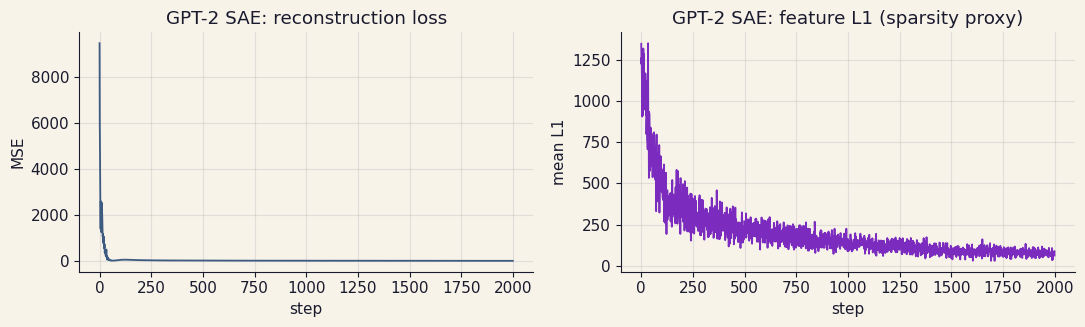

In [14]:
# Plot training trajectory
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(hist_gpt2[:, 1], color=PALETTE["indigo"], lw=1.3)
ax[0].set_xlabel("step"); ax[0].set_ylabel("MSE")
ax[0].set_title("GPT-2 SAE: reconstruction loss")
ax[0].grid(alpha=0.3)

ax[1].plot(hist_gpt2[:, 2], color=PALETTE["plum"], lw=1.3)
ax[1].set_xlabel("step"); ax[1].set_ylabel("mean L1")
ax[1].set_title("GPT-2 SAE: feature L1 (sparsity proxy)")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
# --- Find features that have actually specialized, and the tokens that maximally activate them ---
with torch.no_grad():
    F_gpt2 = sae_gpt2.encode(torch.from_numpy(acts_np))  # (N_tokens, D_FEAT)

F_gpt2_np = F_gpt2.numpy()
firing_gpt2 = (F_gpt2_np > 1e-3).mean(axis=0)
print(f"alive features (firing rate > 0.5%): {(firing_gpt2 > 0.005).sum()} / {D_FEAT}")
print(f"dead features (never fire): {(firing_gpt2 == 0).sum()} / {D_FEAT}")
print(f"mean firing rate of alive features: {firing_gpt2[firing_gpt2 > 0.005].mean()*100:.1f}%")

# Sparsity sanity check: average number of features active per token.
live_per_token = (F_gpt2_np > 1e-3).sum(axis=1).mean()
print(f"average features active per token: {live_per_token:.1f} of {D_FEAT}")

# Pick features that fire on a small but non-trivial fraction of tokens — these are the ones
# most likely to be selective. (Features that fire on every token are uninformative.)
candidates = np.where((firing_gpt2 > 0.01) & (firing_gpt2 < 0.2))[0]
print(f"\n{len(candidates)} candidate features in the 1%–20% firing range")

# Within candidates, prefer features whose top activation is large relative to their mean
# (i.e., they have a distinctive peak rather than a flat profile). This is a coarse
# stand-in for "specificity."
peakiness = []
for fi in candidates:
    col = F_gpt2_np[:, fi]
    nz = col[col > 1e-3]
    if len(nz) < 3:
        peakiness.append(-np.inf)
        continue
    peakiness.append(nz.max() / (nz.mean() + 1e-6))
peakiness = np.array(peakiness)
TOP_K_FEATURES = candidates[np.argsort(-peakiness)[:5]]
print(f"top 5 most peaked features: {TOP_K_FEATURES.tolist()}")

alive features (firing rate > 0.5%): 174 / 3072
dead features (never fire): 2682 / 3072
mean firing rate of alive features: 5.4%
average features active per token: 9.9 of 3072

143 candidate features in the 1%–20% firing range
top 5 most peaked features: [2541, 463, 2756, 370, 939]


In [16]:
# For each top feature, print the top-5 tokens (with a tiny context window) that maximally activate it.
def context(rec_idx, n=3):
    s, t, _ = token_records[rec_idx]
    # gather neighboring tokens from the same sentence
    same = [r for r in token_records if r[0] == s]
    lo = max(0, t - n); hi = min(len(same), t + n + 1)
    return "".join(r[2] for r in same[lo:hi]).replace("\n", " ")

for fi in TOP_K_FEATURES:
    acts_f = F_gpt2[:, fi].numpy()
    top = np.argsort(-acts_f)[:5]
    print(f"\n--- feature {fi}  (firing rate {firing_gpt2[fi]*100:.1f}%) ---")
    for ti in top:
        s_idx, t_idx, t_str = token_records[ti]
        ctx = context(ti, n=3)
        print(f"  act={acts_f[ti]:5.2f}  token={repr(t_str):15s}  ctx={repr(ctx)}")


--- feature 2541  (firing rate 3.2%) ---
  act= 2.80  token='mes'            ctx=' grated parmesan.'
  act= 0.86  token='an'             ctx='ated parmesan.'
  act= 0.58  token=' par'           ctx=' freshly grated parmesan.'
  act= 0.32  token='os'             ctx=' np.zeros((10,'
  act= 0.11  token=' World'         ctx=' after the Second World War.'

--- feature 463  (firing rate 4.5%) ---
  act= 2.40  token='umpy'           ctx='import numpy as np;'
  act= 1.11  token=' np'            ctx=' numpy as np; arr ='
  act= 0.69  token=' np'            ctx='; arr = np.zeros'
  act= 0.52  token='acci'           ctx='def fibonacci(n):'
  act= 0.45  token=' tuple'         ctx=' function returns a tuple of (mean'

--- feature 2756  (firing rate 3.1%) ---
  act= 1.81  token=' strong'        ctx='Tech companies reported strong earnings in the'
  act= 0.67  token=' turbulent'     ctx=' Friday after a turbulent week.'
  act= 0.56  token=' significant'   ctx='forest produces a significant fraction

**Read the output above carefully and be honest with yourself.**

Some features will look interpretable — maybe one fires on punctuation, one on Python identifiers, one on capital letters, one on common function words. Others will look like noise: a grab-bag of tokens with no obvious theme. **That is the expected outcome at this scale.** With 50 sentences and 1500 training steps, you simply do not have enough signal to fully untangle 768-dim residual streams. Training noise dominates.

The Anthropic Claude-3 Sonnet SAE found features for "the Golden Gate Bridge that fires on text descriptions, on images of the bridge, and on the French phrase 'pont du Golden Gate'." That is what the same procedure looks like at production scale. Same loss function, same architecture, three orders of magnitude more data and compute. The mechanism is identical. The difference is fuel.

## 5 · Demo 3 — feature steering ("Golden Gate Claude" in miniature)

Here is the part that, when it works at scale, feels genuinely magical.

Once you have a feature direction $W_\mathrm{dec}[:, i]$ in residual stream space, you can **inject** it into the model at inference time. You run a forward pass, but at layer 6 you replace `residual` with `residual + α · W_dec[:, i]`. Now feature $i$ is artificially "on" with strength $\alpha$, regardless of the input. The downstream layers don't know the difference — they just see a residual stream where that feature's direction is excited.

Anthropic did this with the Golden Gate feature on Claude-3 Sonnet and the model started obsessively talking about the bridge. They called it "Golden Gate Claude" and put it on claude.ai for a day. It was, by all accounts, an extremely funny chatbot.

We're going to do the same thing on our toy GPT-2 SAE. **It will not be magical** — our SAE features are coarse and our model is small. But the *mechanism* is identical. If you understand this code, you understand how Golden Gate Claude works.

In [17]:
# Pick one of our top features to steer with.
STEER_FEATURE = int(TOP_K_FEATURES[0])
direction = sae_gpt2.W_dec.detach()[:, STEER_FEATURE].clone()  # (768,)
direction = direction / direction.norm()  # unit norm
direction = direction.to(device)
print(f"steering with feature {STEER_FEATURE}, direction norm = {direction.norm().item():.3f}")

steering with feature 2541, direction norm = 1.000


In [18]:
# --- Hook that adds α · direction to the residual stream at layer LAYER ---
class Steerer:
    def __init__(self, alpha):
        self.alpha = alpha
        self.handle = None
    def hook(self, module, inp, out):
        h = out[0] if isinstance(out, tuple) else out
        h = h + self.alpha * direction
        if isinstance(out, tuple):
            return (h,) + out[1:]
        return h
    def __enter__(self):
        self.handle = gpt2.transformer.h[LAYER].register_forward_hook(self.hook)
        return self
    def __exit__(self, *a):
        self.handle.remove()

def generate(prompt, alpha=0.0, max_new=20, temperature=0.8, seed=0):
    torch.manual_seed(seed)
    enc = tok(prompt, return_tensors="pt")
    ids = enc.input_ids.to(device)
    attn = enc.attention_mask.to(device)
    with torch.no_grad():
        if alpha == 0.0:
            out = gpt2.generate(ids, attention_mask=attn, max_new_tokens=max_new,
                                do_sample=True, temperature=temperature, top_p=0.9,
                                pad_token_id=tok.eos_token_id)
        else:
            with Steerer(alpha):
                out = gpt2.generate(ids, attention_mask=attn, max_new_tokens=max_new,
                                    do_sample=True, temperature=temperature, top_p=0.9,
                                    pad_token_id=tok.eos_token_id)
    return tok.decode(out[0], skip_special_tokens=True)

prompt = "The weather today is"
print("--- baseline (alpha = 0) ---")
print(generate(prompt, alpha=0.0, seed=1))
print("\n--- steered (alpha = 4) ---")
print(generate(prompt, alpha=4.0, seed=1))
print("\n--- steered hard (alpha = 10) ---")
print(generate(prompt, alpha=10.0, seed=1))

--- baseline (alpha = 0) ---
The weather today is pretty good, so there's no reason not to take it as a cue to start the day off

--- steered (alpha = 4) ---
The weather today is pretty good, so there's no reason not to take it as a cue to start the day off

--- steered hard (alpha = 10) ---
The weather today is good and sunny. We're happy to offer a great selection of food in the evenings. We also


**Be honest with what you see.** If we're lucky, the steered generations are slightly different from the baseline — maybe a vocabulary shift, maybe the topic drifts. If the steering is too gentle, nothing visible happens. If it's too strong, the model degenerates into garbage because we're shoving the residual stream off the manifold of natural activations.

That brittleness is *also* present at production scale, by the way — the Anthropic team had to carefully tune the clamping value to get a "Golden Gate Claude" that was funny rather than incoherent. The right intensity is feature-specific and finicky.

The *mechanism*, again, is what matters: **we found a direction in activation space that we can name (with enough work), and we steered the model's behavior by adding that direction**. No fine-tuning, no prompt engineering, no RLHF. Just vector addition, in the right basis. That is what an unscrambled feature space buys you.

## 6 · Break it on purpose — what does sparsity actually do?

The L1 penalty is a single scalar in the loss function. It would be reasonable to suspect it doesn't matter much. Reasonable, and wrong.

Let's retrain the synthetic SAE with $\lambda = 0$ — no sparsity penalty at all — and see what happens.

In [19]:
# Retrain the synthetic SAE with NO L1 penalty (and no unit-norm constraint either —
# both are part of what enforces sparsity, and we want to see what an unconstrained
# overcomplete autoencoder actually learns).
sae_dense, hist_dense = train_sae(X, d_features=64, l1_coeff=0.0, steps=3000, verbose=False, unit_norm=False)

with torch.no_grad():
    F_dense = sae_dense.encode(torch.from_numpy(X).float())
F_dense_np = F_dense.numpy()
firing_dense = (F_dense_np > 1e-3).mean(axis=0)
n_alive_dense = (firing_dense > 0.005).sum()
mean_active_dense = (F_dense_np > 1e-3).sum(axis=1).mean()
F_pred_np = F_pred.numpy() if hasattr(F_pred, 'numpy') else F_pred
mean_active_sparse = (F_pred_np > 1e-3).sum(axis=1).mean()
print(f"WITH L1:    alive features {(firing > 0.005).sum():2d} / 64,   active features per input: {mean_active_sparse:5.1f}")
print(f"WITHOUT L1: alive features {n_alive_dense:2d} / 64,   active features per input: {mean_active_dense:5.1f}")
print(f"\n(Reminder: the data was generated with ~3 of 20 true features active per input.)")

# Cosine match to ground truth
W_dec_dense = sae_dense.W_dec.detach().numpy()
abs_cos_dense = np.abs(W_dec_dense.T @ P_unit)
best_per_true_dense = abs_cos_dense.max(axis=0)
print(f"\nbest cosine match to TRUE features:")
print(f"  WITH L1:    mean {best_match_per_true.mean():.3f}, min {best_match_per_true.min():.3f}")
print(f"  WITHOUT L1: mean {best_per_true_dense.mean():.3f}, min {best_per_true_dense.min():.3f}")

WITH L1:    alive features 60 / 64,   active features per input:  11.0
WITHOUT L1: alive features 60 / 64,   active features per input:  21.7

(Reminder: the data was generated with ~3 of 20 true features active per input.)

best cosine match to TRUE features:
  WITH L1:    mean 0.815, min 0.693
  WITHOUT L1: mean 0.539, min 0.414


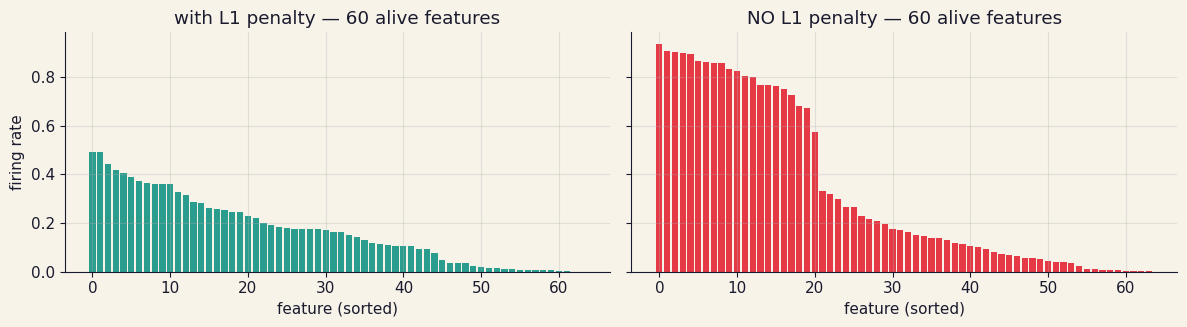

In [20]:
# Side by side: feature firing histograms with and without sparsity.
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)

order_s = np.argsort(-firing)
order_d = np.argsort(-firing_dense)
ax[0].bar(range(64), firing[order_s], color=PALETTE["teal"])
ax[0].set_title(f"with L1 penalty — {(firing > 0.005).sum()} alive features")
ax[0].set_xlabel("feature (sorted)"); ax[0].set_ylabel("firing rate")
ax[0].grid(alpha=0.3)

ax[1].bar(range(64), firing_dense[order_d], color=PALETTE["rose"])
ax[1].set_title(f"NO L1 penalty — {n_alive_dense} alive features")
ax[1].set_xlabel("feature (sorted)")
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

Look at the print-out above carefully. The most striking gap is **active features per input**:

- The L1-penalized SAE has on the order of ~12 features active per input. (Still more than the ground-truth 3, but in the right ballpark.)
- The unpenalized SAE has *every* feature active on *every* input. Dense, useless.
- **Reconstruction is fine in both cases!** The unpenalized SAE reconstructs the input perfectly — it has 64 dims fitting an 8-dim vector, of course it does. The cosine match to ground-truth features may even be similar in absolute magnitude. But the *interpretability story collapses*, because a feature that fires on every input means nothing.

This is the difference between *reconstruction* and *interpretability*. A dense overcomplete autoencoder is just a redundant change of basis — you can do that with PCA, with SVD, with a random matrix, nobody cares. **The L1 penalty is what forces the optimizer to find a basis where only a few features are active per input**, and that per-example sparsity — plus the overcompleteness — is the precise condition under which the recovered features can correspond to identifiable concepts.

Sparsity is doing all the work. Take it away and the dictionary becomes a hash table.

## 7 · The SAE bestiary (ReLU, TopK, Gated, JumpReLU)

The vanilla L1 SAE we just built is great pedagogy and pretty good in practice, but the field has moved on. The variants all attack the same nuisance: the **L1 penalty has a bias**. It pushes feature activations toward zero even when the features are real and the data wants them large. So you trade off: turn L1 up, get sparser features but worse reconstruction; turn L1 down, get better reconstruction but denser features. There is no setting where you get both.

Each modern variant tries to break that tradeoff:

- **TopK SAE** (OpenAI, 2024). Replace the L1 penalty with a hard constraint: *only the top-$k$ features per input are allowed to fire, all others are zeroed.* No L1, no shrinkage bias. The downside is that $k$ is now a hard hyperparameter and dead features are trickier to revive. Cleaner Pareto frontier in practice.
- **Gated SAE** (DeepMind, 2024). Decouple "should this feature fire?" from "how much should it fire?" Use a separate gating sub-network for the binary decision and an unbiased magnitude path for the value. Fixes the L1 shrinkage at the cost of more parameters.
- **JumpReLU SAE** (DeepMind, August 2024). Replace ReLU with a *jump* nonlinearity: features below a learned threshold are exactly zero, features above the threshold are passed through with their unbiased magnitude. The whole **GemmaScope** open-source SAE suite uses JumpReLU.
- **Transcoder SAEs** (2024). Instead of reconstructing the input, predict the *next layer*'s activations from the current layer's. This makes the features causally aligned with the model's computation, not just descriptively aligned with its representations.
- **Crosscoders** (Anthropic, 2024–2025, ICLR 2025). Train a single SAE that takes activations from *several layers* (or even several models) at once, learning shared features across them. Useful for "model diffing" — what changed between Sonnet 3.5 and Sonnet 3.6 at the feature level.
- **BatchTopK / Matryoshka TopK / PAnneal**. Variations on the TopK theme that pool sparsity across batches or anneal from dense to sparse during training.

The pattern is consistent: every variant is a different answer to "how do we enforce sparsity without distorting the magnitudes." There is, as of 2026, no single winner. Different variants beat each other on different metrics, and in many published comparisons the careful baseline is competitive with the new method.

The takeaway for this notebook: vanilla L1 is the conceptual core, the variants are quality-of-life improvements, and the real research question is upstream — **what should we do with the features once we have them?**

## 8 · Why anyone outside academia cares

If SAEs were just a way to make pretty visualizations, they'd be a fun curiosity. They're not. The reason every frontier lab now has an interpretability team running SAEs is that they unlock concrete, ship-blocking workflows:

- **Hallucination debugging.** A model says something false. You look at which SAE features were active in the residual stream during the hallucinated tokens. Often you find that a "I'm confident" feature was firing alongside an "I'm guessing" feature, with the wrong one winning. You now know *what* to fix, not just *that* something is broken.
- **Deception detection.** Anthropic found explicit features for "the model is being deceptive" and "the model is reasoning about its own training." You can monitor those features at inference time. If they fire during a safety-relevant query, you flag the response. This is the closest thing to an internal lie detector that exists.
- **Pre-deployment auditing.** Before you serve a fine-tuned model, you train an SAE on its residual stream and check whether any new features have appeared, or whether existing safety-relevant features have weakened. This is "feature drift" monitoring and it's becoming standard practice.
- **Fine-grained steering.** Instead of fine-tuning a model to be more polite, you find the politeness feature and clamp it. No new training run, no risk of catastrophic forgetting. Reversible at inference time.
- **Circuits work.** Once you have features, you can ask *what computes them and what they compute*. This is the **circuits** program from Olah et al. — wiring diagrams of how features in layer $\ell$ get assembled from features in layer $\ell-1$. SAEs make circuits tractable because circuits over neurons are hopeless (superposition!) but circuits over features are sometimes legible.

None of this requires SAEs to be perfect. They're already useful at the messy, partial level we've reached today. The gap between "we can name 30% of the alive features" and "we can name 70%" is the gap between current research and the next round of papers.

## 9 · Checkpoint quiz

Five questions. Answer them in your head before peeking at the spoiler.

**1.** Why must $k > d$ in the SAE? What goes wrong with $k = d$ or $k < d$?

**2.** What concrete failure mode does unit-normalizing the decoder columns prevent?

**3.** In the synthetic demo, the L1 SAE did NOT cleanly produce 20 alive and 44 dead features — most features had some non-zero activity. Why is "dead-feature pruning" not what an L1 SAE actually does, and which SAE variants enforce it more sharply?

**4.** What does the L1 penalty *actually* do that PCA / SVD does not, given that both can produce overcomplete bases?

**5.** You train an SAE on a base model, fine-tune the base model, and find that one previously-dead feature is now alive on 5% of inputs. What might you do with that observation?

---

<details>
<summary>Answers</summary>

**1.** With $k \le d$ you can't have more *features* than the dimensionality of the activation space, which is exactly what superposition requires. You'd be learning rotated PCA — useful for compression, useless for unscrambling overlapping features. The whole point of the SAE is to lift the activations into a higher-dimensional space *where* the features are linearly separable; that requires more output dimensions than input dimensions.

**2.** Without unit-norm decoder columns, the optimizer has a degenerate solution: shrink every $f_i(x)$ toward zero (which the L1 loves) and inflate $W_\mathrm{dec}[:, i]$ by the inverse factor (free for the reconstruction). The L1 norm collapses, the reconstruction is unchanged, and you've learned nothing. Unit-norming closes the loophole: shrinking activations now actually costs reconstruction.

**3.** L1 is a *shrinkage* penalty, not a hard sparsity constraint. It pushes magnitudes toward zero proportional to the gradient of the L1 norm, which is constant — so small activations get shrunk to zero, but only just barely, and the boundary is fuzzy. You get a graded distribution of feature firing rates rather than a clean alive/dead split. **TopK SAEs** (OpenAI 2024) enforce hard sparsity by zeroing all but the top-$k$ activations per input. **JumpReLU SAEs** (DeepMind 2024) use a learned hard threshold below which features are exactly zero. Both produce much cleaner alive/dead splits, which is one of the reasons the field has largely moved to them for production-scale work. The flip side: dead features can become *truly* dead, and you need explicit resurrection tricks to bring them back.

**4.** PCA/SVD give you an *orthogonal* basis ranked by variance. Overcomplete PCA doesn't even make sense — once you have $d$ orthogonal directions in $d$-dim space you're done. The L1-penalized SAE is doing something fundamentally different: it gives up orthogonality, allows $k > d$ overlapping non-orthogonal directions, and uses sparsity (only a few features active per input) as the constraint that picks out a *unique* basis. This is closer to **sparse coding** (Olshausen & Field 1996) than to PCA, and the optimal basis under sparse coding is provably *not* the PCA basis when the data is sparse in a non-orthogonal basis — which is exactly the superposition setting.

**5.** Investigate that feature. It's a fingerprint of what the fine-tune *changed* about the model's representations. Look at the inputs that activate it, look at the tokens that change in generation when you ablate it, look at whether it correlates with safety features you care about. This is the basic "feature drift" workflow for pre-deployment auditing — it would have been impossible without SAEs because the change at the *neuron* level is obfuscated by superposition.

</details>

## 10 · Bridge to Part VII

We've spent six parts building, scaling, training, aligning, and interpreting models. Part VII pivots: now we serve them.

That sounds like a hard left turn, but it isn't. The reason interpretability matters operationally is that **before you serve a model to users at scale, you should have some idea what it's thinking**. Continuous batching and PagedAttention make the model fast; SAEs and circuits make the model knowable. You want both. The teams that ship the next generation of frontier models are going to monitor SAE features in production the same way SREs monitor request latency today.

Part VII is the plumbing — vLLM, paged KV cache, request scheduling, distributed inference, model routing. By the end of it you will be able to take any of the models we built and put them behind an OpenAI-compatible endpoint that handles a thousand concurrent requests. And when one of those requests gets a weird response, you'll have the vocabulary to ask not just "*what* did the model say" but "*which features fired when it said it*."

Onward.